# <center>**La poule qui chante (entreprise française d’agroalimentaire)**</center>

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Importation des librairies et chargement des données</h2>
</div>

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Importation des librairies et chargement des données</h3>
</div>

In [1]:
# Importation des librairies
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import os
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Chargement des données et 'Code Pays' en index
df = pd.read_csv(r"D:\$27.12.2025 Ordinateur\$29.12.2025 Bureau\$GRETA\$P11\df_final_pour_analyse.csv", decimal=",", sep=";", index_col='Code Pays')
names = df.index

In [3]:
# Supprime 'Zone' ET on ne garde AUTOMATIQUEMENT que les colonnes numériques
X_numeric = df.drop(['Zone'], axis=1, errors='ignore').select_dtypes(include=[np.number])

# Extrait la liste des noms de ces variables numériques pour vos prints
df_num = X_numeric.columns.tolist()

# Exécute dans la cellule d'origine en haut de ton notebook
df_backup = df_num.copy()

# Extrait la matrice brute (uniquement des chiffres désormais !)
X_brut = X_numeric.values

print("✅ Données chargées et filtrées !")
print(f"Pays : {len(df)}")
print(f"Variables numériques retenues : {len(df_num)}")
print()
for i, col in enumerate(df_num):
    print(f"{i+1}. {col}")

display(df.head())

print("\n--------")
print("RÉSUMÉ STATISTIQUES :")
display(X_numeric.describe())

✅ Données chargées et filtrées !
Pays : 134
Variables numériques retenues : 13

1. Disponibilité alimentaire en quantité (kg/personne/an)
2. Disponibilité intérieure (en milliers de tonnes)
3. Exportations - Quantité (en milliers de tonnes)
4. Importations - Quantité (en milliers de tonnes)
5. Production (en milliers de tonnes)
6. Population
7. PIB (en millions d'USD)
8. Nombre de personnes n'ayant pas les moyens de s'offrir une alimentation saine
9. Stability Score
10. Taux de dépendance à l’importation
11. Production en kg par habitant
12. PIB par habitant (en USD)
13. Taux de la population ayant les moyens de s'offrir une alimentation saine (en %)


,Zone,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure (en milliers de tonnes),Exportations - Quantité (en milliers de tonnes),Importations - Quantité (en milliers de tonnes),Production (en milliers de tonnes),Population,PIB (en millions d'USD),Nombre de personnes n'ayant pas les moyens de s'offrir une alimentation saine,Stability Score,Taux de dépendance à l’importation,Production en kg par habitant,PIB par habitant (en USD),Taux de la population ayant les moyens de s'offrir une alimentation saine (en %)
Code Pays,,,,,,,,,,,,,,
ZAF,Afrique du Sud,35.69,2118.0,63.0,514.0,1667.0,57009756.0,3.811367e+05,35000000.0,-0.38,24.268178,29.240609,6685.464789,39
ALB,Albanie,16.36,47.0,0.0,38.0,13.0,2884169.0,1.301973e+04,700000.0,0.16,74.509804,4.507364,4514.205415,76
DZA,Algérie,6.38,277.0,0.0,2.0,275.0,41389189.0,1.700970e+05,7800000.0,-0.93,0.722022,6.644247,4109.696067,81
DEU,Allemagne,19.47,1739.0,646.0,842.0,1514.0,82658409.0,3.763092e+06,2300000.0,0.70,49.239766,18.316346,45525.825010,97
AGO,Angola,10.56,319.0,0.0,277.0,42.0,29816766.0,1.221239e+05,18400000.0,-0.54,86.833856,1.408603,4095.811665,38



--------
RÉSUMÉ STATISTIQUES :


,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure (en milliers de tonnes),Exportations - Quantité (en milliers de tonnes),Importations - Quantité (en milliers de tonnes),Production (en milliers de tonnes),Population,PIB (en millions d'USD),Nombre de personnes n'ayant pas les moyens de s'offrir une alimentation saine,Stability Score,Taux de dépendance à l’importation,Production en kg par habitant,PIB par habitant (en USD),Taux de la population ayant les moyens de s'offrir une alimentation saine (en %)
count,134.000000,134.000000,134.000000,134.000000,134.000000,1.340000e+02,1.340000e+02,1.340000e+02,134.000000,134.000000,134.000000,134.000000,134.000000
mean,17.909030,818.880597,122.104478,88.231343,868.634328,5.207813e+07,5.640011e+05,2.029403e+07,-0.155821,33.208750,18.024579,12826.288588,64.649254
std,13.802427,2440.388247,512.754485,182.356171,2778.086150,1.722355e+08,2.078595e+06,8.024554e+07,0.814843,40.367385,18.059468,17611.690646,26.432282
min,0.130000,2.000000,0.000000,0.000000,0.000000,2.070890e+05,3.785989e+02,1.000000e+05,-2.220000,0.000000,0.000000,450.900697,3.000000
25%,5.892500,47.000000,0.000000,2.250000,26.500000,4.622526e+06,1.344016e+04,7.000000e+05,-0.700000,1.966515,2.565515,1861.243099,40.500000
50%,16.250000,131.000000,1.000000,17.500000,102.500000,1.107878e+07,5.787048e+04,3.000000e+06,-0.180000,17.408508,12.932782,5449.473235,71.000000
75%,27.270000,424.750000,26.000000,83.500000,523.000000,3.734761e+07,3.261378e+05,1.037500e+07,0.557500,60.119048,27.004160,14904.795767,88.750000
max,67.390000,18266.000000,4223.000000,1069.000000,21914.000000,1.421022e+09,1.961210e+07,8.049000e+08,1.490000,233.103448,76.299320,82215.816862,99.000000


<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Fonctions</h3>
</div>

In [4]:
# GRAPHIQUE CERCLE DES CORÉLATIONS

def correlation_graph(pca, 
                      x_y, 
                      features) : 
    
    # Extrait x et y 
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(30, 30))

    # Pour chaque composante : 
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0, 
                pca.components_[x, i],  
                pca.components_[y, i],  
                head_width=0.07,
                head_length=0.07, 
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i],
                fontsize=20)
        
    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)),fontsize=35)
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)),fontsize=35)

    # Titre
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1),fontsize=60)

    # Le cercle 
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Standardisation des données</h3>
</div>

In [5]:
# Initialisation du Scaler (sklearn)
scaler = StandardScaler()

# On scale à partir des données numériques uniquement (13 colonnes) -> array NumPy en sortie
X_scaled_array = scaler.fit_transform(X_numeric)

# On reconstruit le DataFrame avec les index et les 13 bonnes colonnes
X_scaled = pd.DataFrame(
    X_scaled_array,
    index=df.index,
    columns=df_num 
)

# Affichage pour vérification
X_scaled.describe().round(2)

,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure (en milliers de tonnes),Exportations - Quantité (en milliers de tonnes),Importations - Quantité (en milliers de tonnes),Production (en milliers de tonnes),Population,PIB (en millions d'USD),Nombre de personnes n'ayant pas les moyens de s'offrir une alimentation saine,Stability Score,Taux de dépendance à l’importation,Production en kg par habitant,PIB par habitant (en USD),Taux de la population ayant les moyens de s'offrir une alimentation saine (en %)
count,134.00,134.00,134.00,134.00,134.00,134.00,134.00,134.00,134.00,134.00,134.00,134.00,134.00
mean,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.29,-0.34,-0.24,-0.49,-0.31,-0.30,-0.27,-0.25,-2.54,-0.83,-1.00,-0.71,-2.34
25%,-0.87,-0.32,-0.24,-0.47,-0.30,-0.28,-0.27,-0.25,-0.67,-0.78,-0.86,-0.62,-0.92
50%,-0.12,-0.28,-0.24,-0.39,-0.28,-0.24,-0.24,-0.22,-0.03,-0.39,-0.28,-0.42,0.24
75%,0.68,-0.16,-0.19,-0.03,-0.12,-0.09,-0.11,-0.12,0.88,0.67,0.50,0.12,0.92
max,3.60,7.18,8.03,5.40,7.60,7.98,9.20,9.81,2.03,4.97,3.24,3.95,1.30


count = 135 pour toutes les variables cela signifie qu'il n'y a aucune donnée manquante
<br>mean = 0 et std = 1 pour chaque variable. Les données sont donc centrées et réduites.
<br>L'écart-type (std) est identique pour chaque variable (= 1), ce qui signifie qu'elles auront toutes le même poids pour la suite de l'étude.

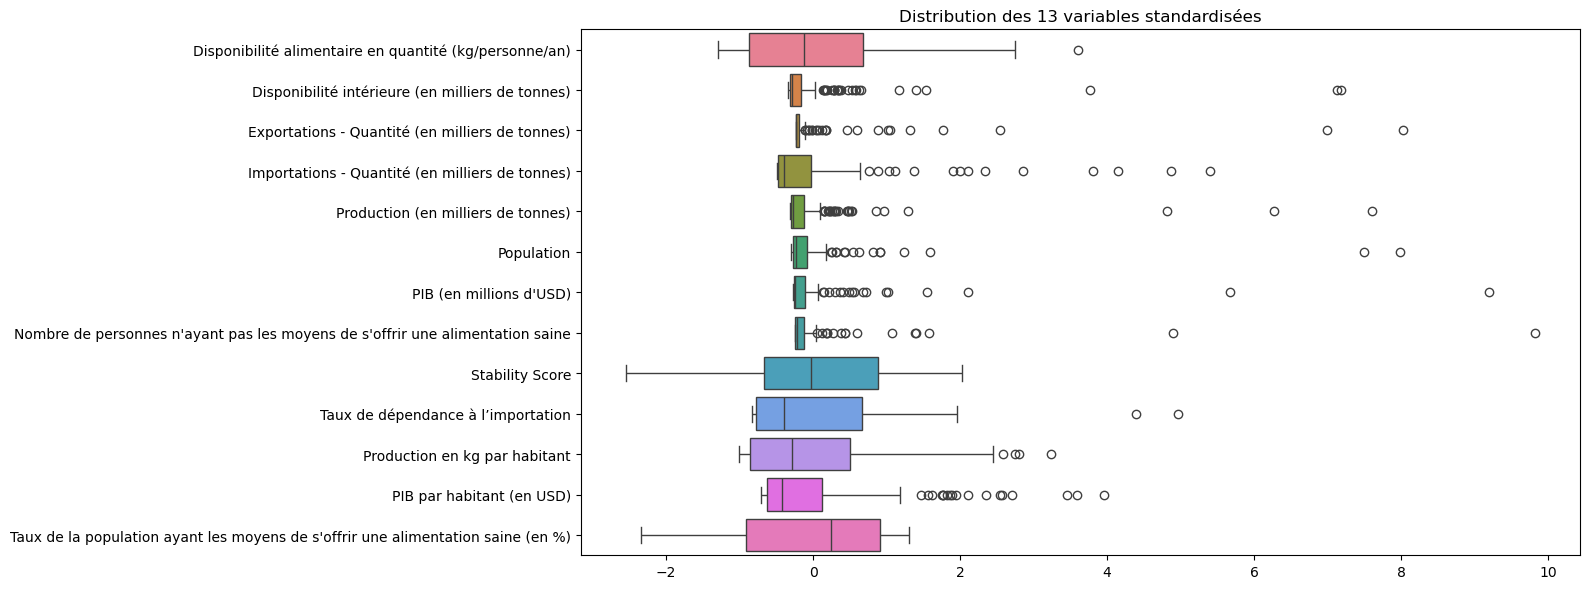

In [6]:
# Visualisation de la distribution des 13 variables

plt.figure(figsize=(16, 6))

sns.boxplot(data=X_scaled, orient="h")
plt.title("Distribution des 13 variables standardisées")
plt.tight_layout()
plt.show()

Les variables comme 'Disponibilité intérieure', 'Exportations', 'Importations', 'Production', 'Population', 'PIB' et 'Nombre de personnes n'ayant pas les moyens de s'offrir une alimentation saine' ont des **boîtes à moustache toutes petites proche de 0**. Cependant, **ces variables possèdent beaucoup d'outliers**.

<br>**Ces 135 pays sont économiquement et démographiquement très inégalitaire.** La grande majorité des 135 pays ont des tailles modestes, tandis qu'une poignée de géants (comme la Chine, l'Inde, les USA) tirent les échelles vers le haut : c'est l'effet de taille.

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Corrélation entre les variables</h3>
</div>

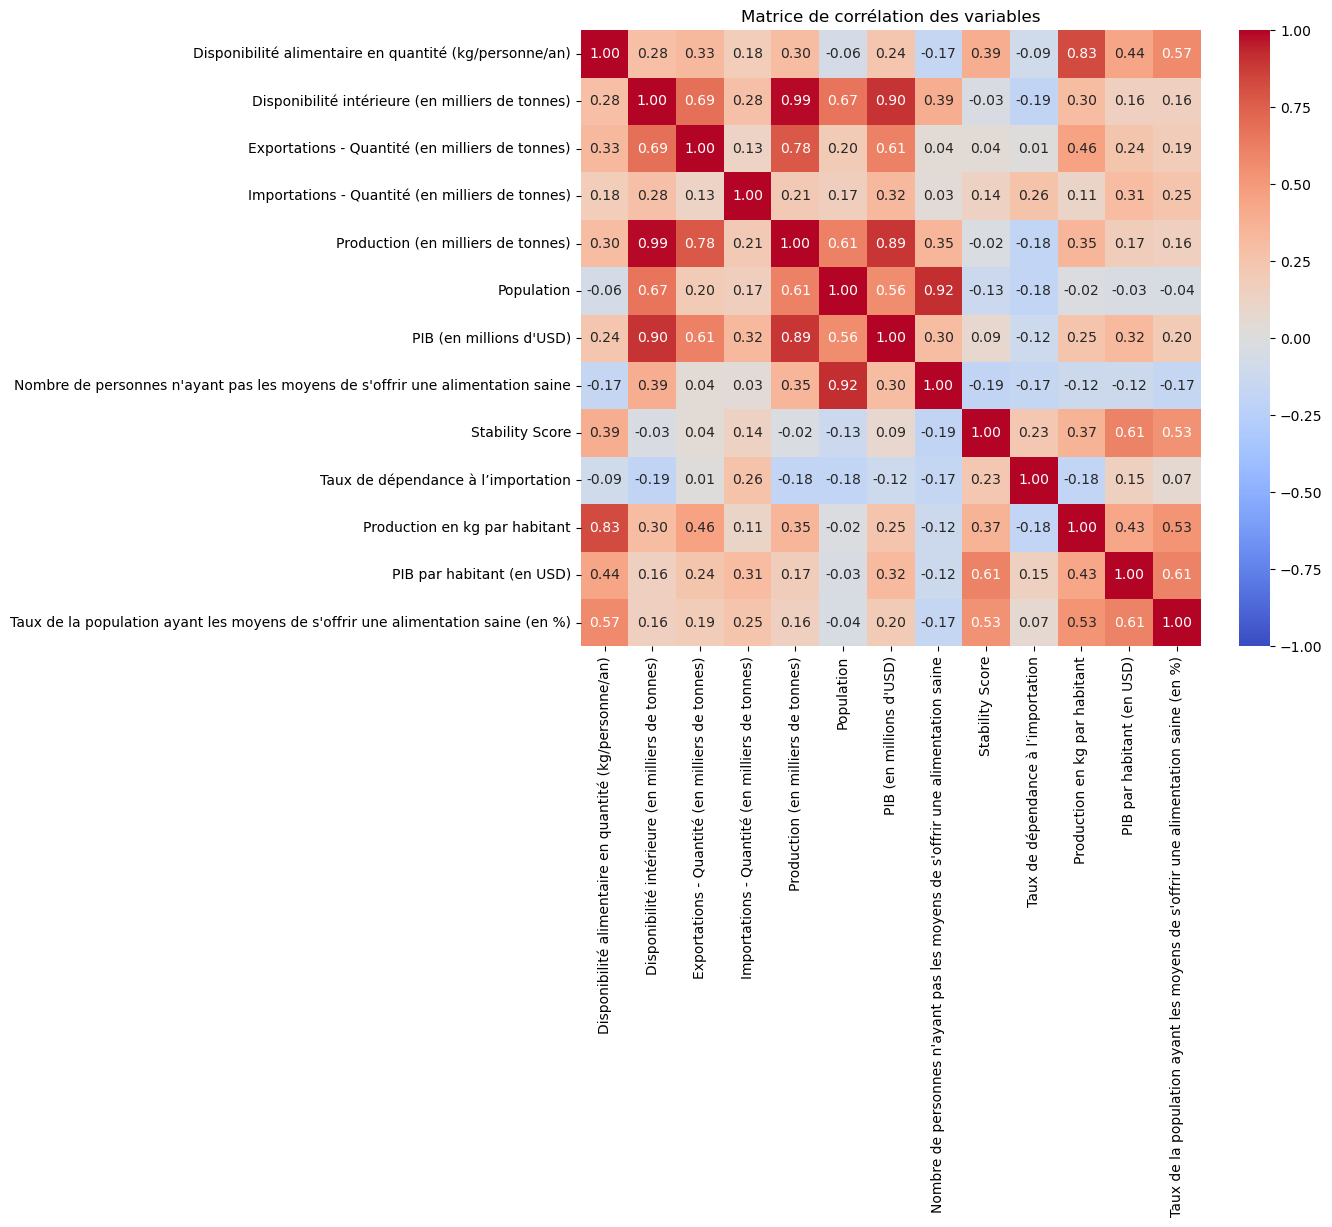

In [7]:
# Mettre en valeur les corrélations (grâce à la Heatmap)

plt.figure(figsize=(10, 8))

sns.heatmap(X_scaled.corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matrice de corrélation des variables")
plt.show()

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">L'ACP</h2>
</div>

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Éboulis des valeurs propres</h3>
</div>

In [8]:
# Initialisation
pca = PCA()

# Entraînement sur les données scalées
pca.fit(X_scaled)

# Calcul des pourcentage de variance
scree = pca.explained_variance_ratio_ * 100
scree_cum = scree.cumsum()

# Résultats dans un tableau
pd.DataFrame({
    'Valeur propre': pca.explained_variance_.round(2),
    'Variance (en %)': scree.round(2),
    'Variance cumulée (en %)': scree_cum.round(2)
}, index=[f'F{i+1}' for i in range(len(scree))])

,Valeur propre,Variance (en %),Variance cumulée (en %)
F1,4.69,35.80,35.80
F2,3.15,24.03,59.83
F3,1.45,11.04,70.87
F4,1.17,8.90,79.77
F5,0.76,5.77,85.54
F6,0.62,4.74,90.28
F7,0.41,3.10,93.38
F8,0.37,2.82,96.20
F9,0.28,2.11,98.31
F10,0.13,1.03,99.34


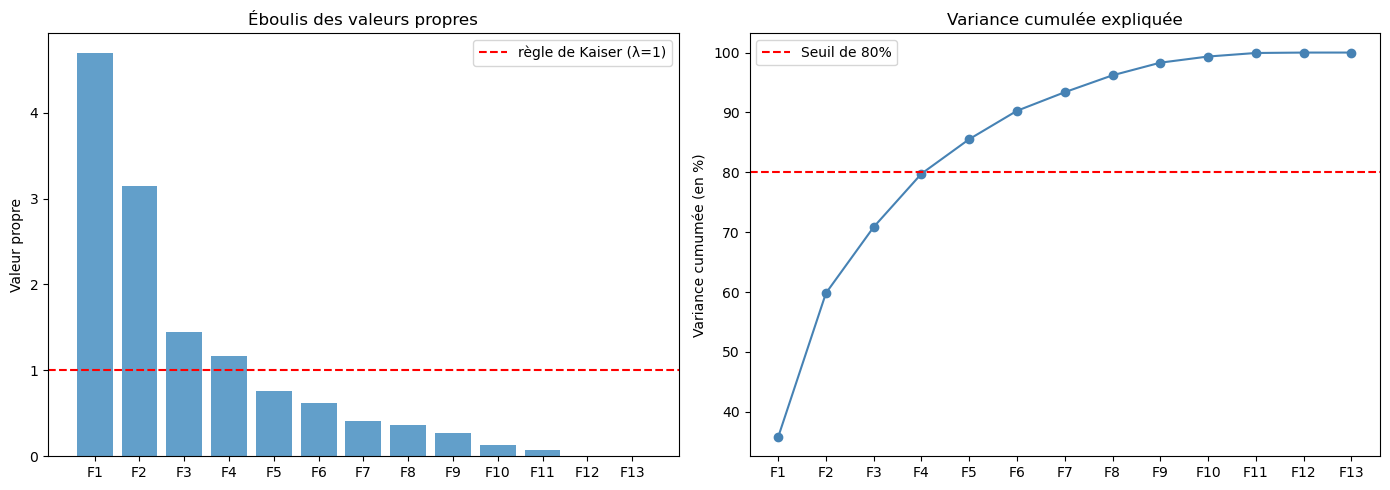

In [9]:
# Graphiques des éboulis et variance cumulée

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
axes = [f'F{i+1}' for i in range(len(scree))]

# Graphique de l'éboulis des valeur propres
ax1.bar(axes, pca.explained_variance_, alpha=0.7)

ax1.axhline(y=1, color='red', linestyle='--', label='règle de Kaiser (λ=1)')
# trace une ligne horizontale rouge en pointillés à y=1 -> le seuil de Kaiser

ax1.set_title('Éboulis des valeurs propres')
ax1.set_ylabel('Valeur propre')
ax1.legend()

# cumulative variance
ax2.plot(axes, scree_cum, marker='o', color='steelblue')
ax2.axhline(y=80, color='red', linestyle='--', label='Seuil de 80%')

ax2.set_title('Variance cumulée expliquée')
ax2.set_ylabel('Variance cumumée (en %)')
ax2.legend()

plt.tight_layout()
plt.show()

Selon la règle de Kaiser, on ne garde que les axes dont la **valeur propre est supérieure à 1 pour les valeurs propres brutes : on garde donc 4 axes.**
<br>On souhaite un seuil de variance cumulée qui permet d'expliquer **80 % de l'inertie totale : on garde donc 4 axes.**

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Nouvelles coordonées pour projection</h3>
</div>

In [10]:
# Initialisation de l'ACP avec 4 axes
pca_4 = PCA(n_components=4)

# Calcul nouvelles coordonnées contenu dans une matrice Numpy
coordinates = pca_4.fit_transform(X_scaled)

# Création du dataframe Pandas
df_coords = pd.DataFrame(
    coordinates,
    index=df.index,
    columns=[f'F{i+1}' for i in range(4)]
)

# Affichage pour vérification
print(df_coords.shape)
df_coords.head()

(134, 4)


,F1,F2,F3,F4
Code Pays,,,,
ZAF,0.908804,0.030128,0.269805,-0.303061
ALB,-0.876762,-0.368257,0.693766,-0.302882
DZA,-0.886558,0.741792,-0.560571,0.109878
DEU,2.744346,-1.635999,2.965127,-0.735092
AGO,-1.086520,0.708515,1.446798,-1.096486


In [11]:
# Récupère les coefficients calculés par l'algorithme de la bibliothèque Scikit-Learn (PCA) et les stocke dans la variable 'pcs'
pcs = pca_4.components_

In [12]:
# Version optimisée avec les bons index et noms de colonnes
pcs = pd.DataFrame(
    pca_4.components_,
    index=[f'F{i+1}' for i in range(4)],
    columns=df_num # on utilise df_num qui contient les 13 variables numériques réelles
)

# Affichage avec un arrondi pour une lecture plus facile/pour simplifier l'analyse
pcs.round(2)

,Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure (en milliers de tonnes),Exportations - Quantité (en milliers de tonnes),Importations - Quantité (en milliers de tonnes),Production (en milliers de tonnes),Population,PIB (en millions d'USD),Nombre de personnes n'ayant pas les moyens de s'offrir une alimentation saine,Stability Score,Taux de dépendance à l’importation,Production en kg par habitant,PIB par habitant (en USD),Taux de la population ayant les moyens de s'offrir une alimentation saine (en %)
F1,0.26,0.42,0.34,0.17,0.42,0.26,0.40,0.15,0.11,-0.06,0.27,0.22,0.21
F2,-0.33,0.20,0.01,-0.08,0.18,0.37,0.13,0.38,-0.38,-0.15,-0.30,-0.34,-0.37
F3,-0.26,-0.02,-0.16,0.49,-0.08,0.20,0.08,0.20,0.24,0.58,-0.34,0.24,0.08
F4,0.14,-0.14,-0.44,-0.14,-0.19,0.38,-0.16,0.50,0.25,-0.37,0.13,0.14,0.23


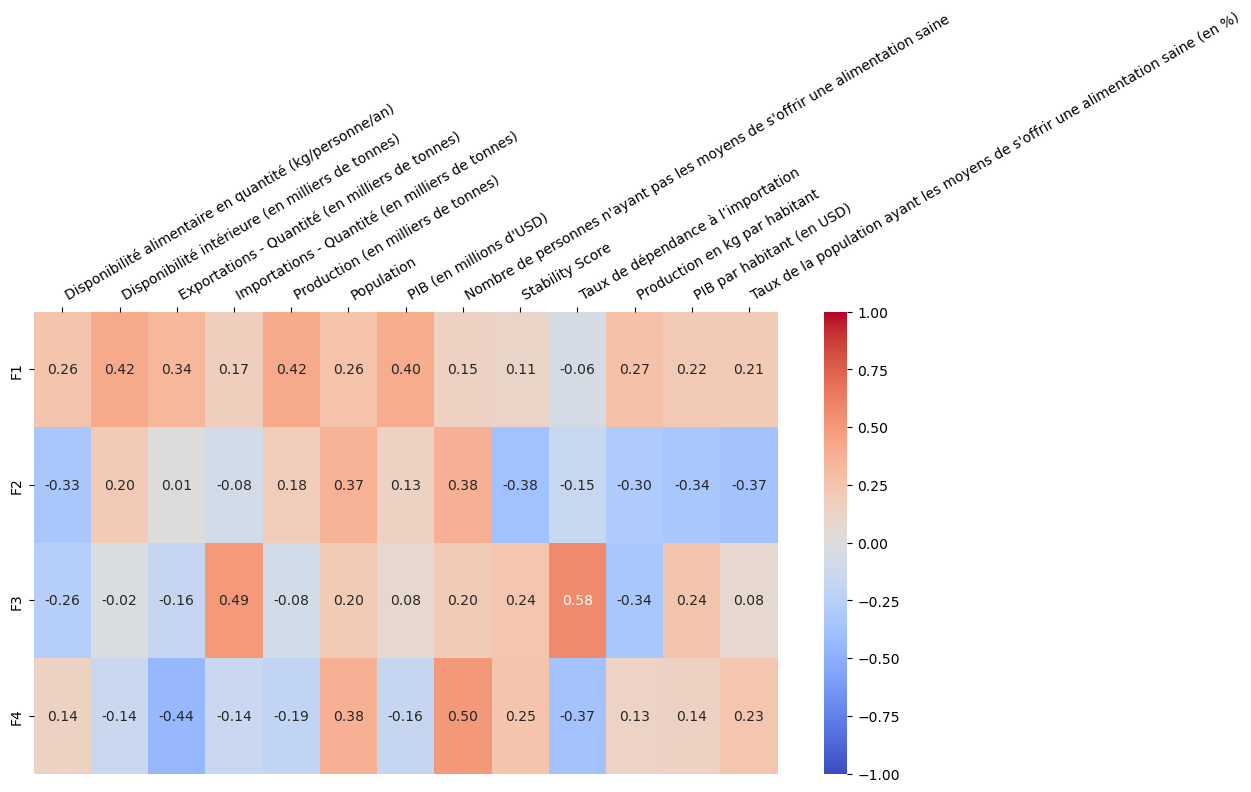

In [13]:
# Représentation visuelle du dataframe
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(pcs, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f", ax=ax)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 

plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.xticks(rotation=30, ha='left')

plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Cercles des corrélations</h3>
</div>

In [14]:
# Fonction utilisée pour faire graphique des cercles des corrélations
x_y = (0,1)
x_y

(0, 1)

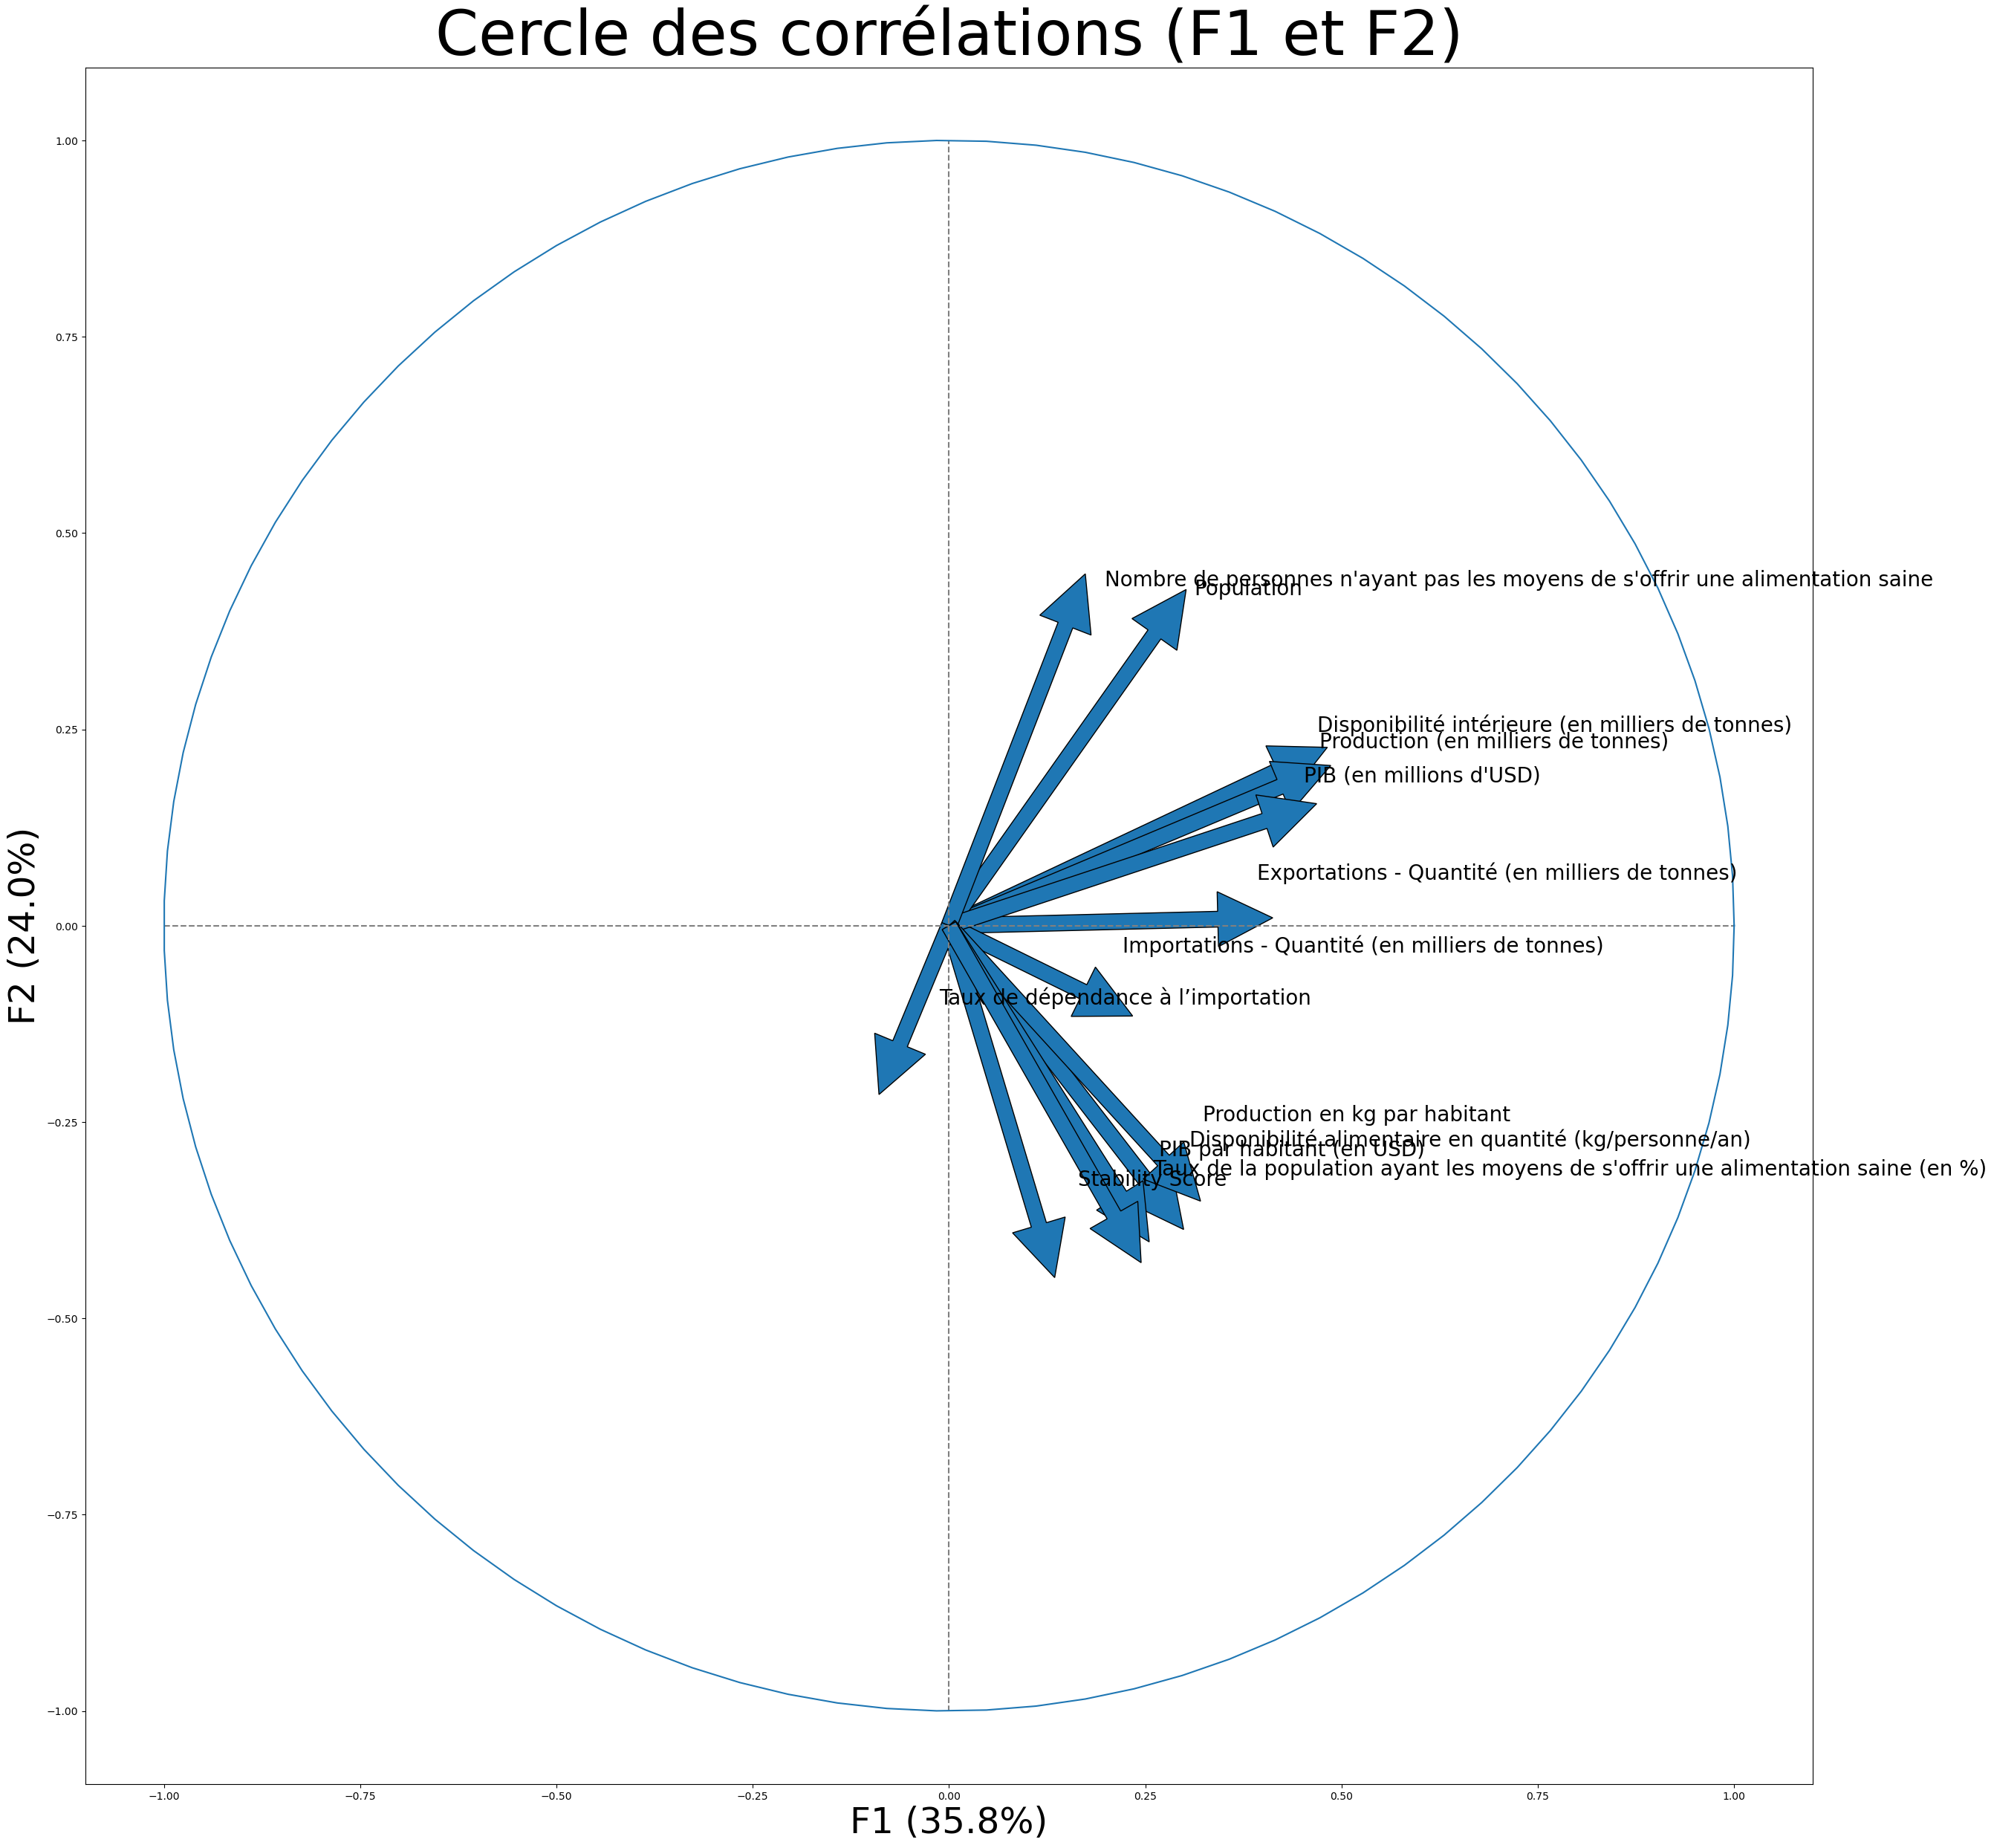

In [15]:
correlation_graph(pca_4, x_y, df_num)

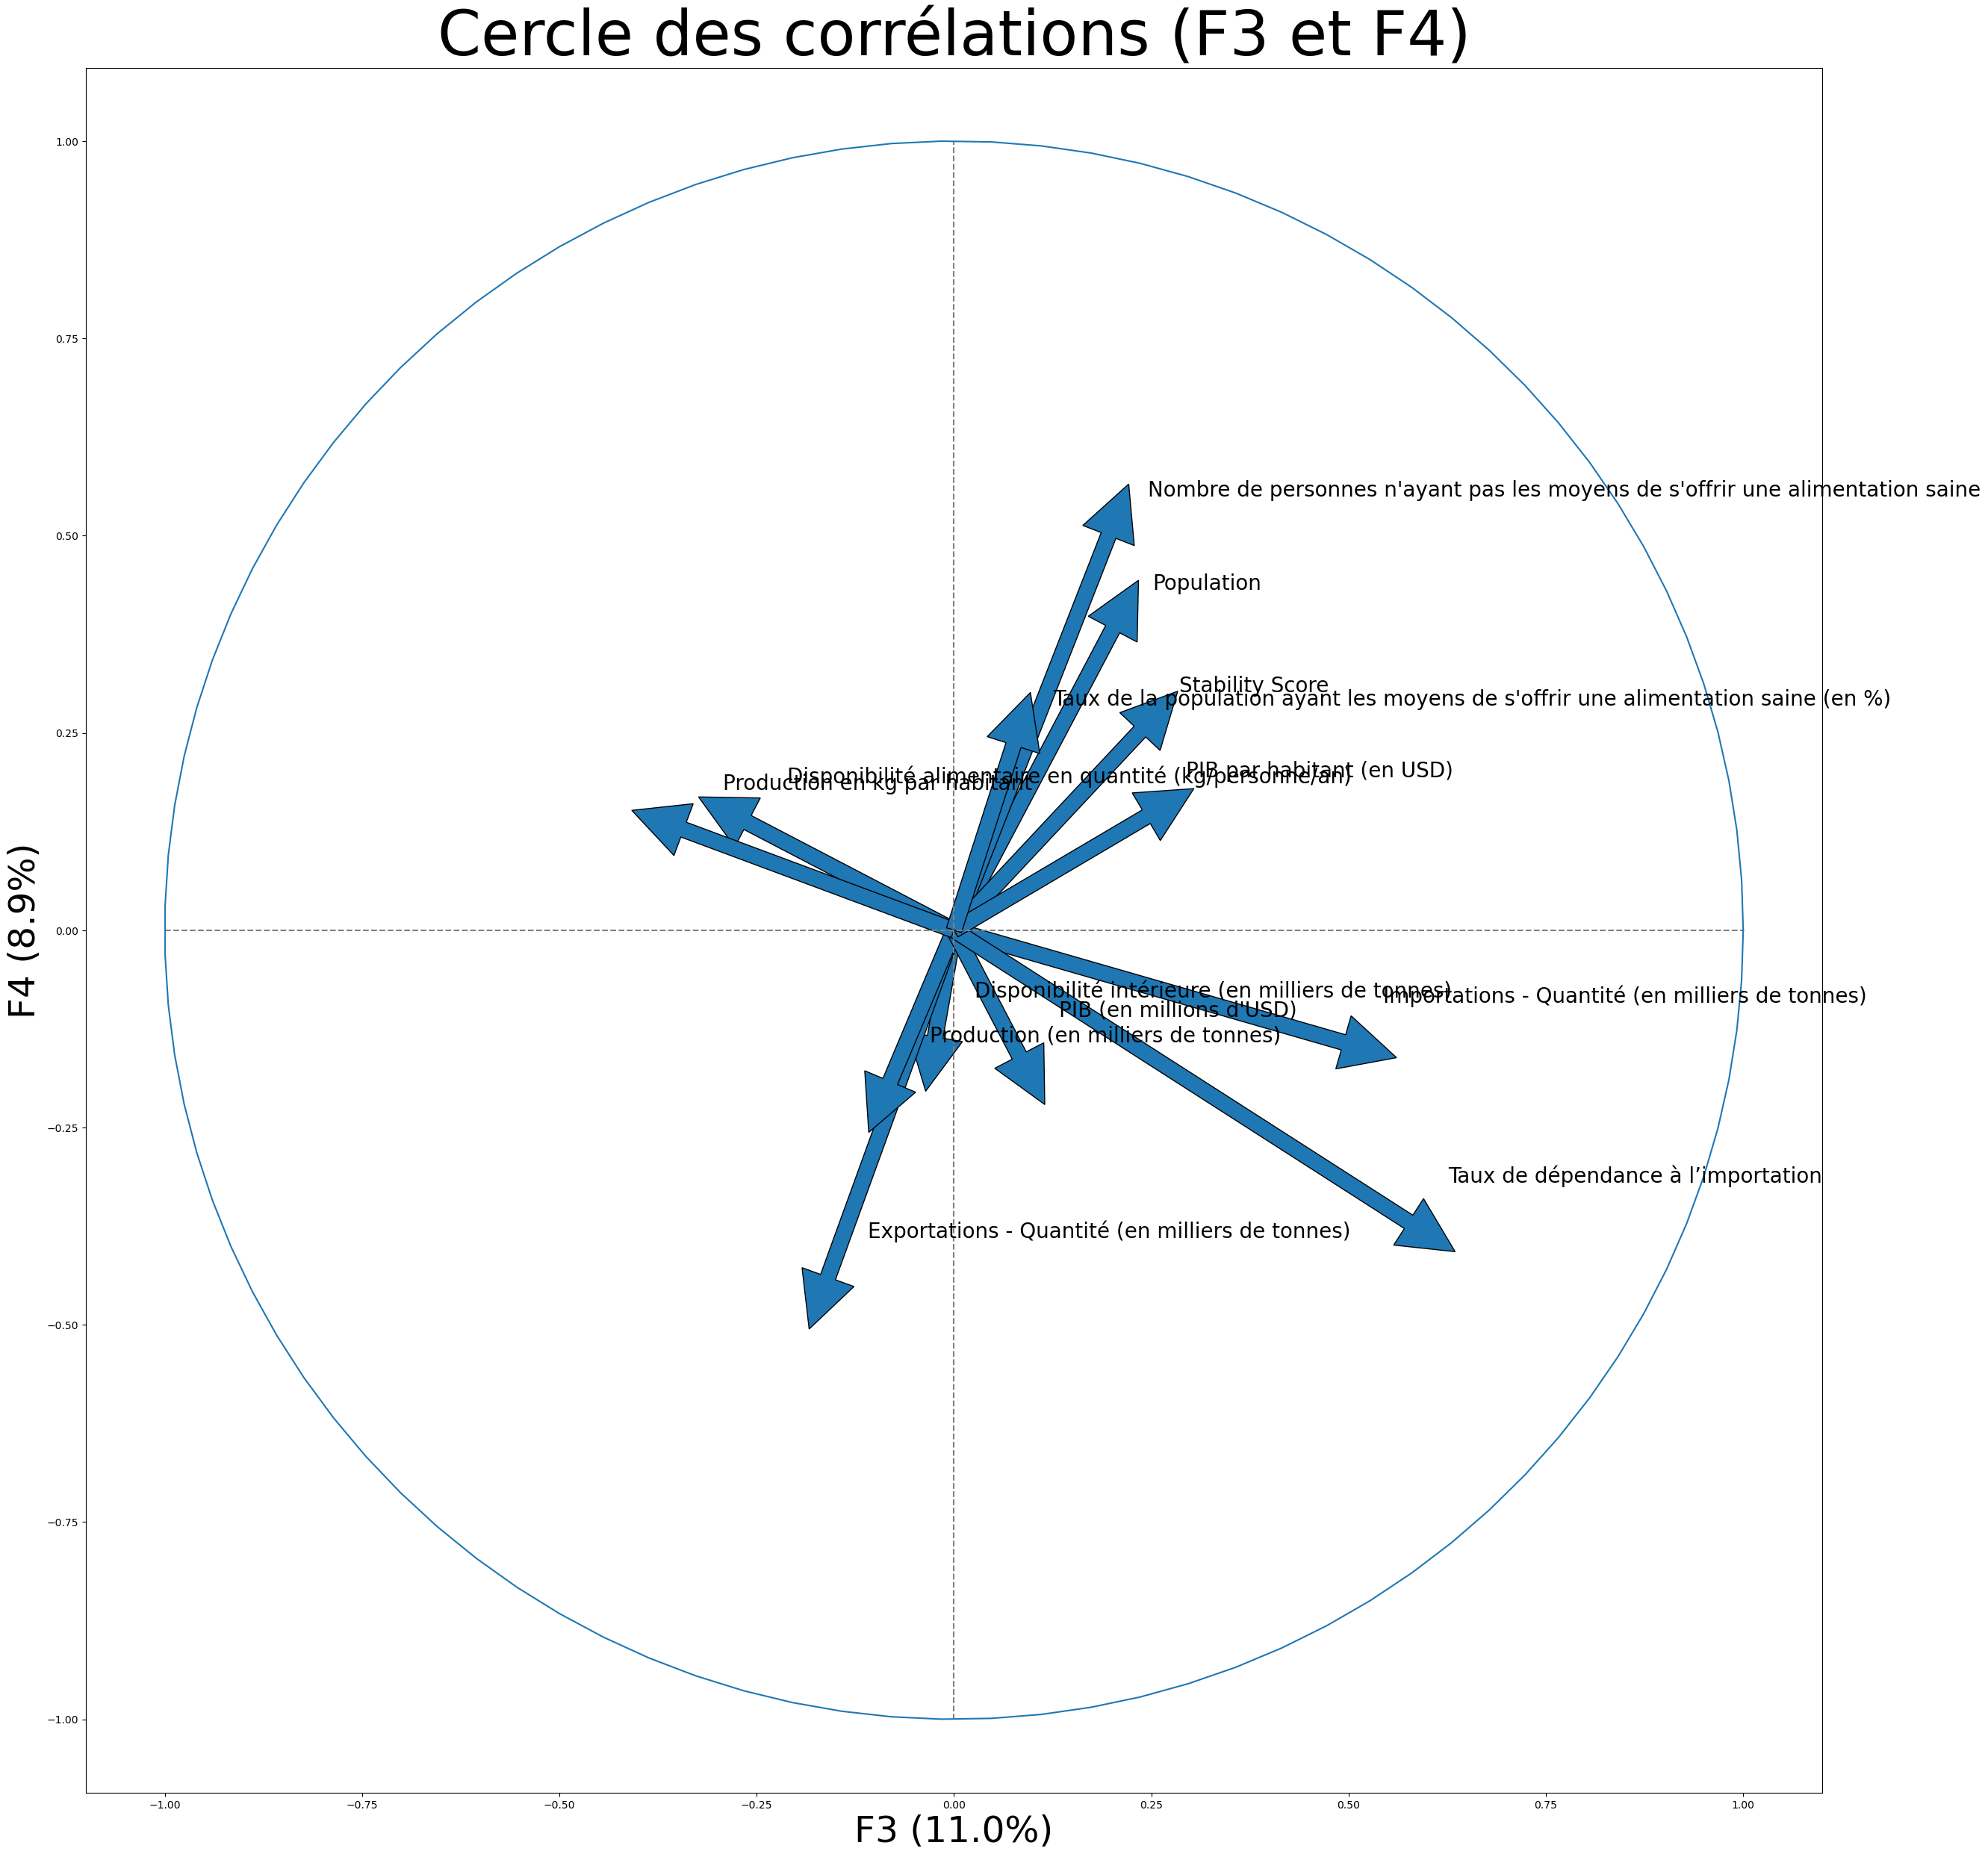

In [16]:
# Pour F3 et F4
correlation_graph(pca_4, (2,3), df_num)

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Projection</h3>
</div>

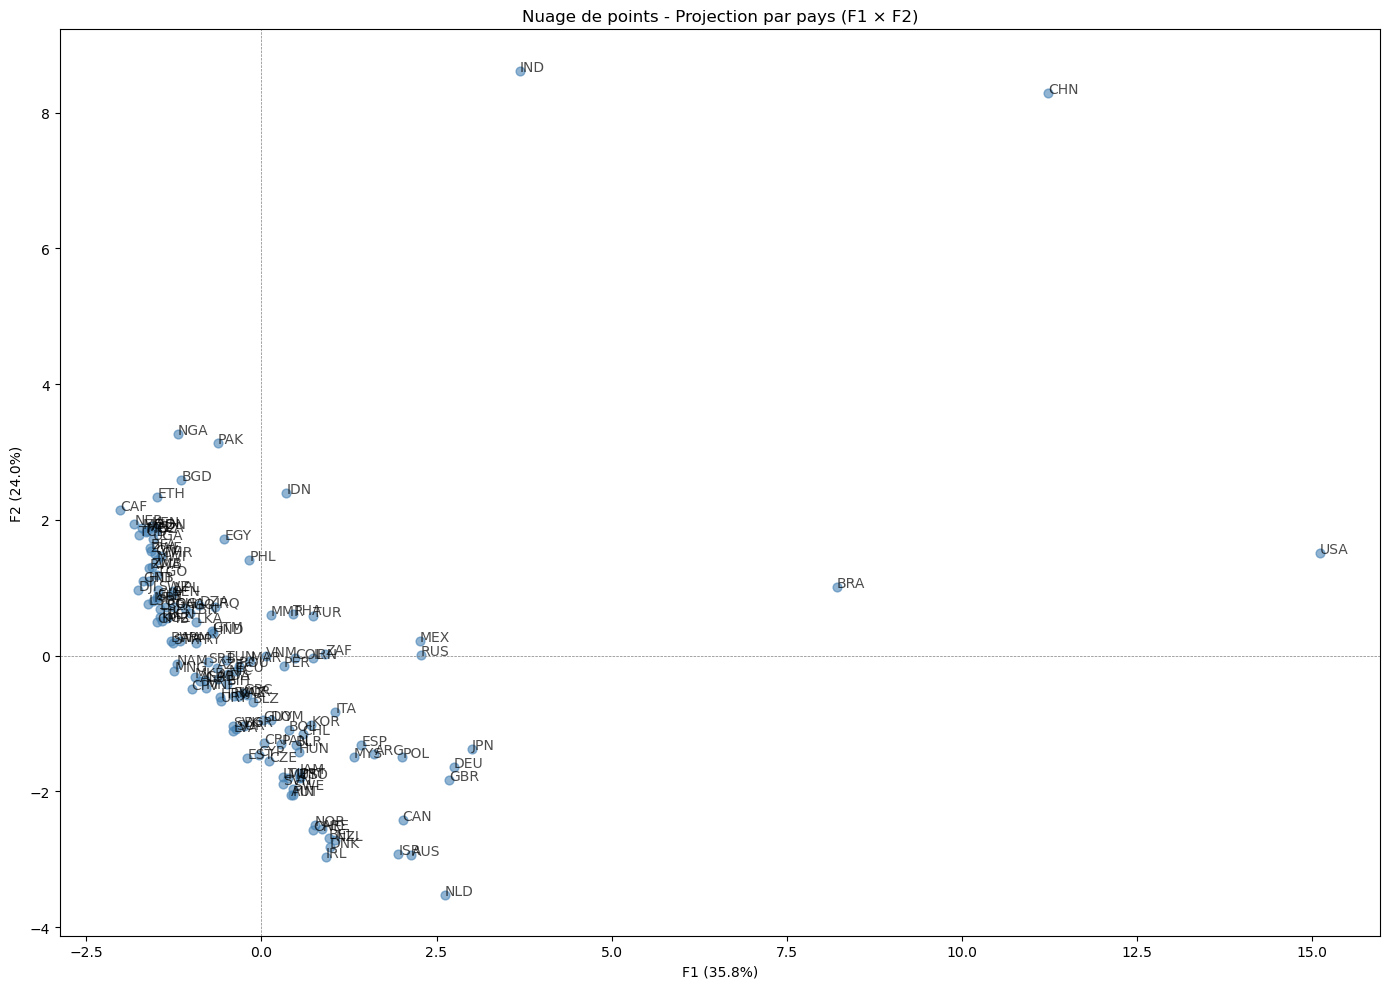

In [17]:
fig, ax = plt.subplots(figsize=(14, 10))

ax.scatter(
    df_coords['F1'], 
    df_coords['F2'], 
    color='steelblue', 
    alpha=0.6, 
    s=40
)

for country in df_coords.index:
    ax.annotate(
        country, 
        xy=(df_coords.loc[country, 'F1'], 
            df_coords.loc[country, 'F2']),
        fontsize=10, alpha=0.7
    )

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax.set_xlabel(f'F1 ({scree[0]:.1f}%)')
ax.set_ylabel(f'F2 ({scree[1]:.1f}%)')
ax.set_title('Nuage de points - Projection par pays (F1 × F2)')

plt.tight_layout()
plt.show()

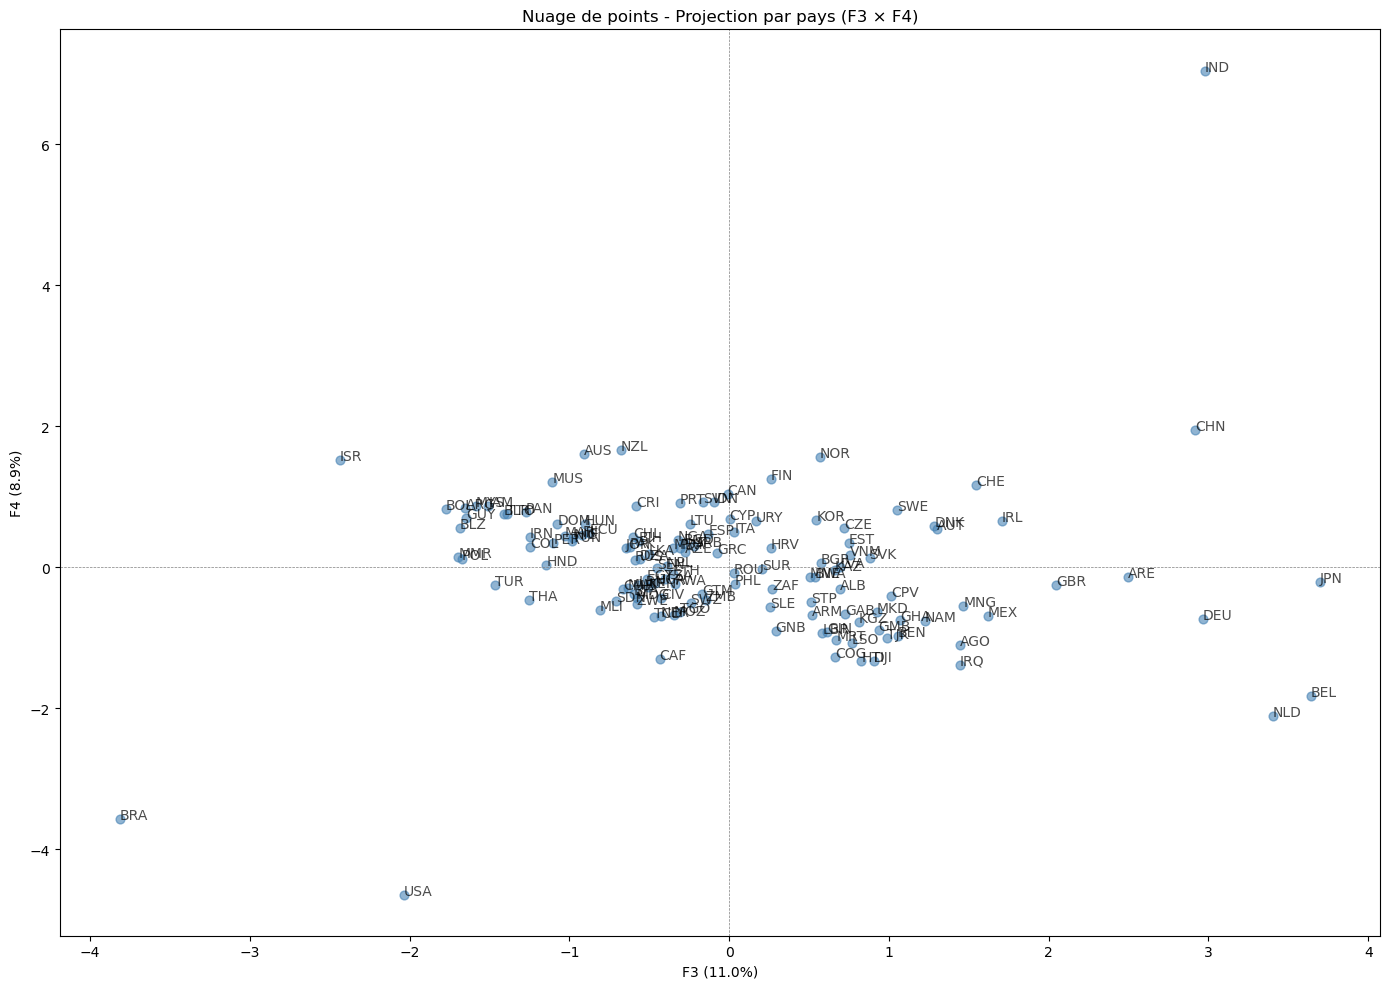

In [18]:
fig, ax = plt.subplots(figsize=(14, 10))

ax.scatter(
    df_coords['F3'], 
    df_coords['F4'], 
    color='steelblue', 
    alpha=0.6, 
    s=40
)

for country in df_coords.index:
    ax.annotate(
        country, 
        xy=(df_coords.loc[country, 'F3'], 
            df_coords.loc[country, 'F4']),
        fontsize=10, alpha=0.7
    )

ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax.set_xlabel(f'F3 ({scree[2]:.1f}%)')
ax.set_ylabel(f'F4 ({scree[3]:.1f}%)')
ax.set_title('Nuage de points - Projection par pays (F3 × F4)')

plt.tight_layout()
plt.show()

<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Classification Hiérarchique Ascendante (CAH)</h2>
</div>

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">Dendogramme</h3>
</div>

In [19]:
df_pca = df_coords[['F1', 'F2', 'F3', 'F4']]

Z = linkage(df_pca, method='ward')

print(f"Z shape: {Z.shape}")

Z shape: (133, 4)


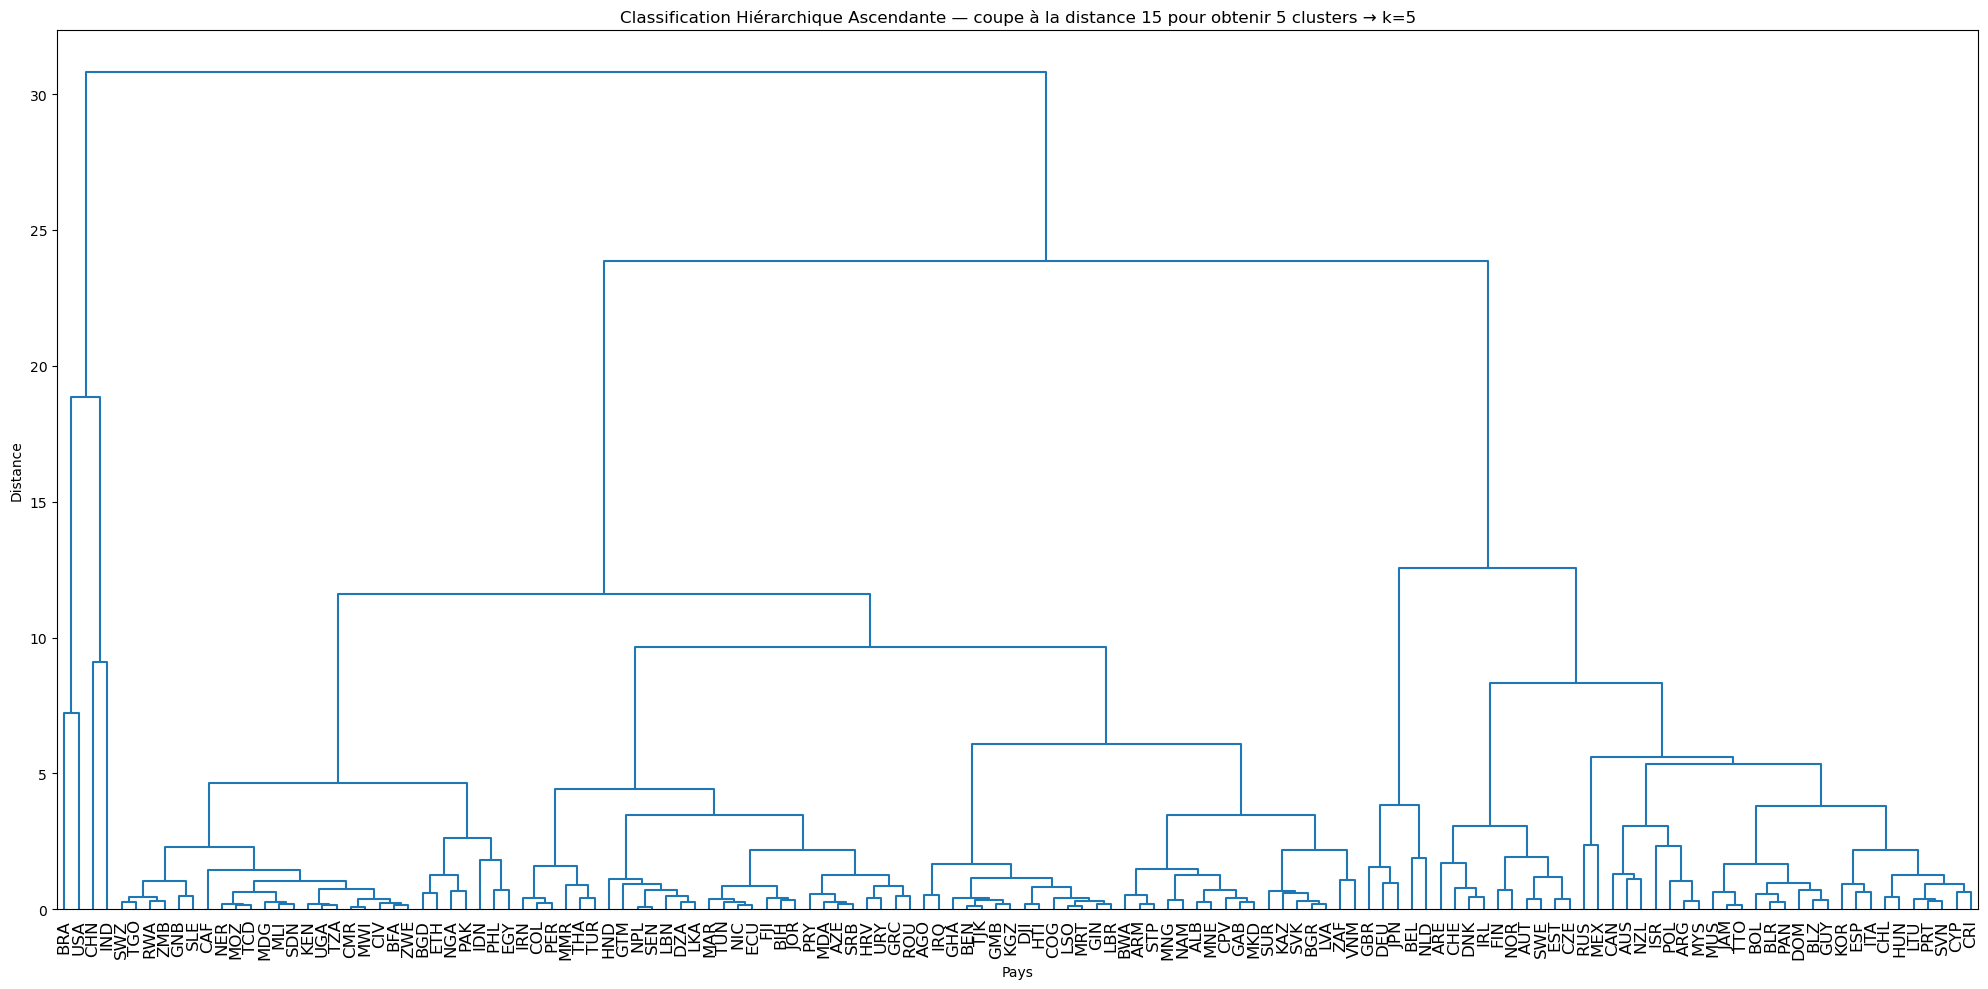

In [20]:
fig, ax = plt.subplots(figsize=(20, 10))

dendrogram(
    Z,
    labels=df_pca.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=12,
    color_threshold=0,
    ax=ax
)

ax.set_title('Classification Hiérarchique Ascendante — coupe à la distance 15 pour obtenir 5 clusters → k=5')
ax.set_xlabel('Pays')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

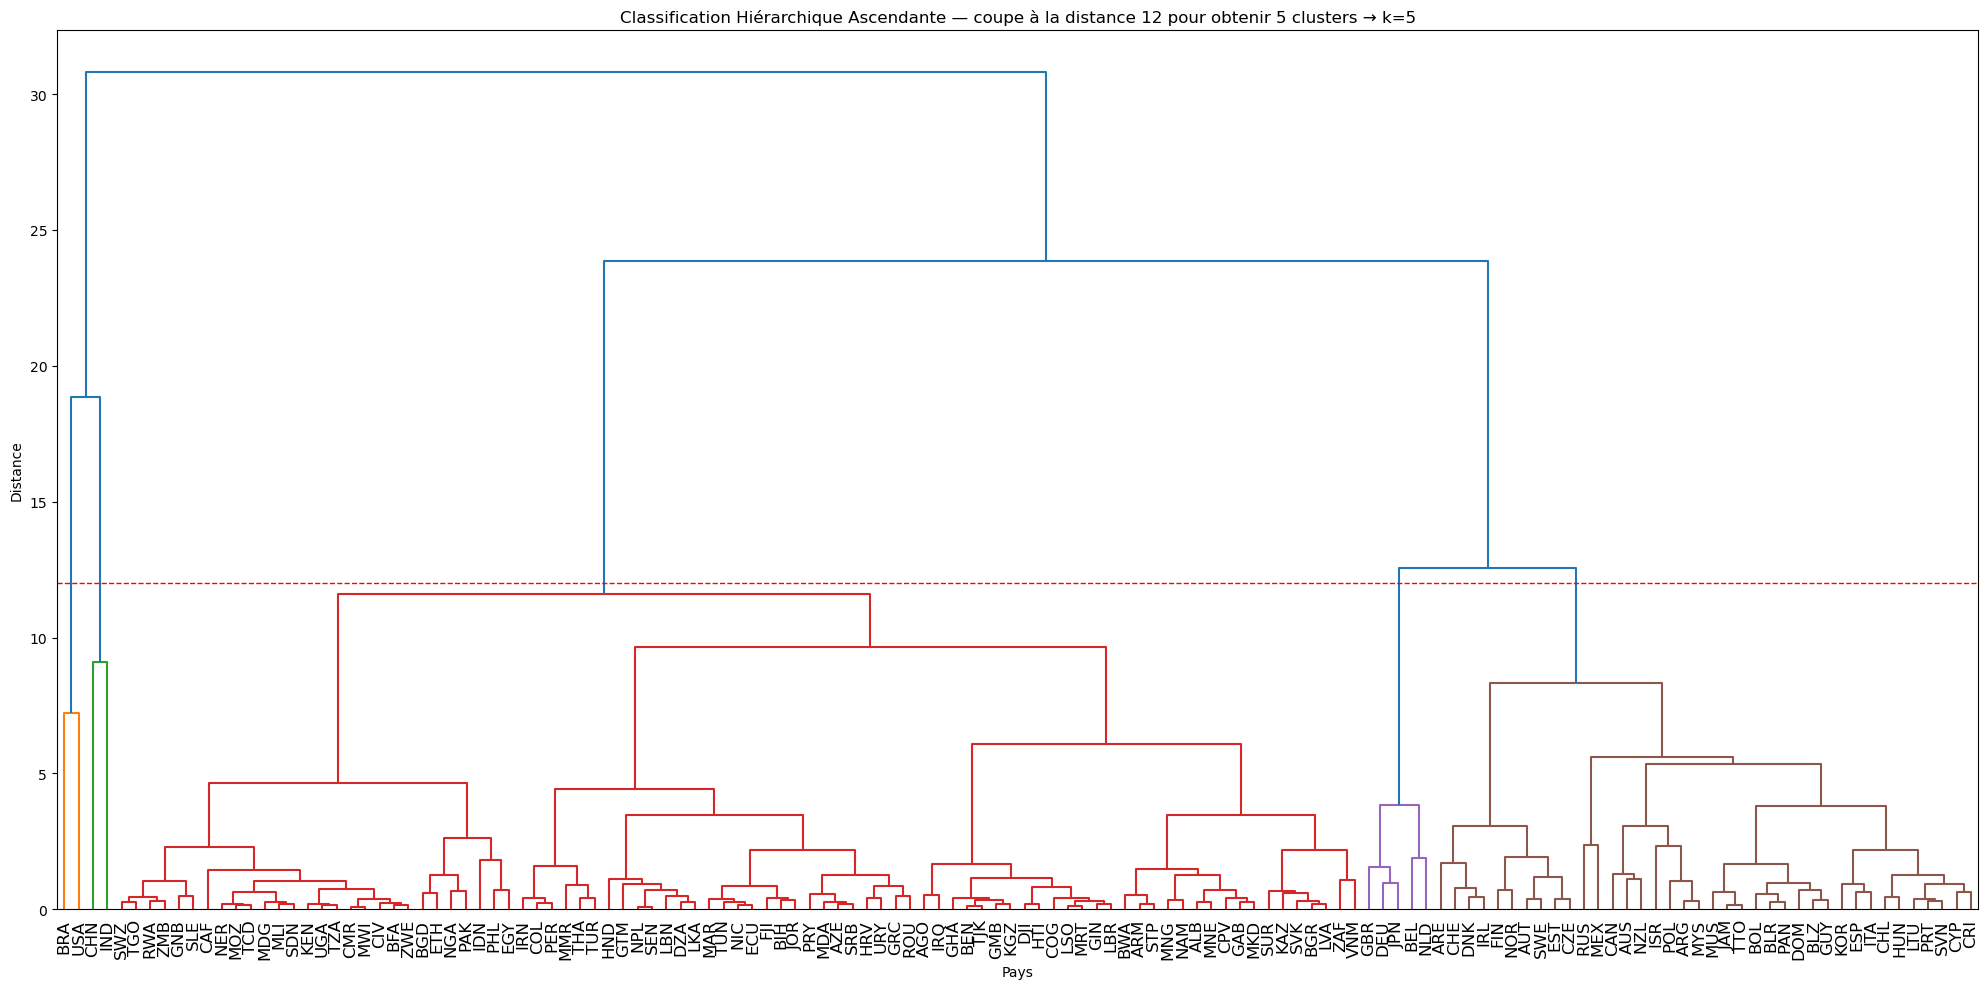

In [21]:
fig, ax = plt.subplots(figsize=(20, 10))

dendrogram(
    Z,
    labels=df_pca.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=12,
    color_threshold=12,
    ax=ax
)

ax.axhline(y=12, color='red', linestyle='--', linewidth=1)

ax.set_title('Classification Hiérarchique Ascendante — coupe à la distance 12 pour obtenir 5 clusters → k=5')
ax.set_xlabel('Pays')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(150, 20, 30);" >
<h3 style="margin: auto; padding: 20px; color: RGB(150, 20, 30); ">K-means</h3>
</div>

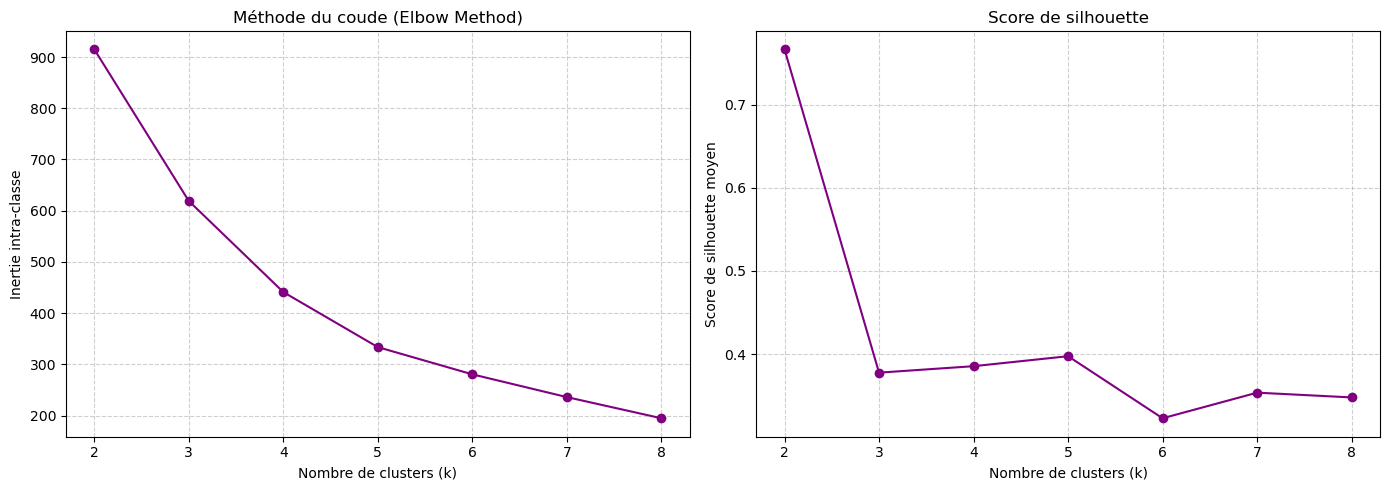

In [22]:
inertias = []
silhouettes = []
K = range(2, 9)  # Teste de 2 à 8 clusters

for k in K:
    # n_init=10 : lance l'algorithme 10 fois avec des centroïdes initiaux différents
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_coords)
    
    # Inertie : somme des carrés des distances des points à leur centroïde (plus elle est basse, plus les clusters sont denses)
    inertias.append(km.inertia_)
    
    # Score de silhouette : mesure à quel point un point ressemble à son propre cluster par rapport aux autres (proche de 1 = excellent)
    silhouettes.append(silhouette_score(df_coords, labels))

# Graphiques côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique de la méthode du coude
ax1.plot(K, inertias, marker='o', color='purple')
ax1.set_title('Méthode du coude (Elbow Method)')
ax1.set_xlabel('Nombre de clusters (k)')
ax1.set_ylabel('Inertie intra-classe')
ax1.grid(True, linestyle='--', alpha=0.6)

# Graphique du score de silhouette
ax2.plot(K, silhouettes, marker='o', color='purple')
ax2.set_title('Score de silhouette')
ax2.set_xlabel('Nombre de clusters (k)')
ax2.set_ylabel('Score de silhouette moyen')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Résultats : k=5
<br>CAH dendrogramme → k=5
<br>Méthode du coude (Elbow method) → k=5 (ligne presque droite jusque 5 avant cassure)
<br>Score de silhouette → k=5 (plutôt que 2 car pas d'intérêt pour analyse d'avoir seulement 2 clusters)

In [23]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)

cluster_labels = km.fit_predict(df_pca) # renvoie un tableau de numéros ou d'étiquettes de cluster (0, 1, 2, 3, 4) pour chaque pays

df_coords['cluster'] = cluster_labels

print(df_coords['cluster'].value_counts().sort_index())

cluster
0    57
1    61
2     2
3     2
4    12
Name: count, dtype: int64


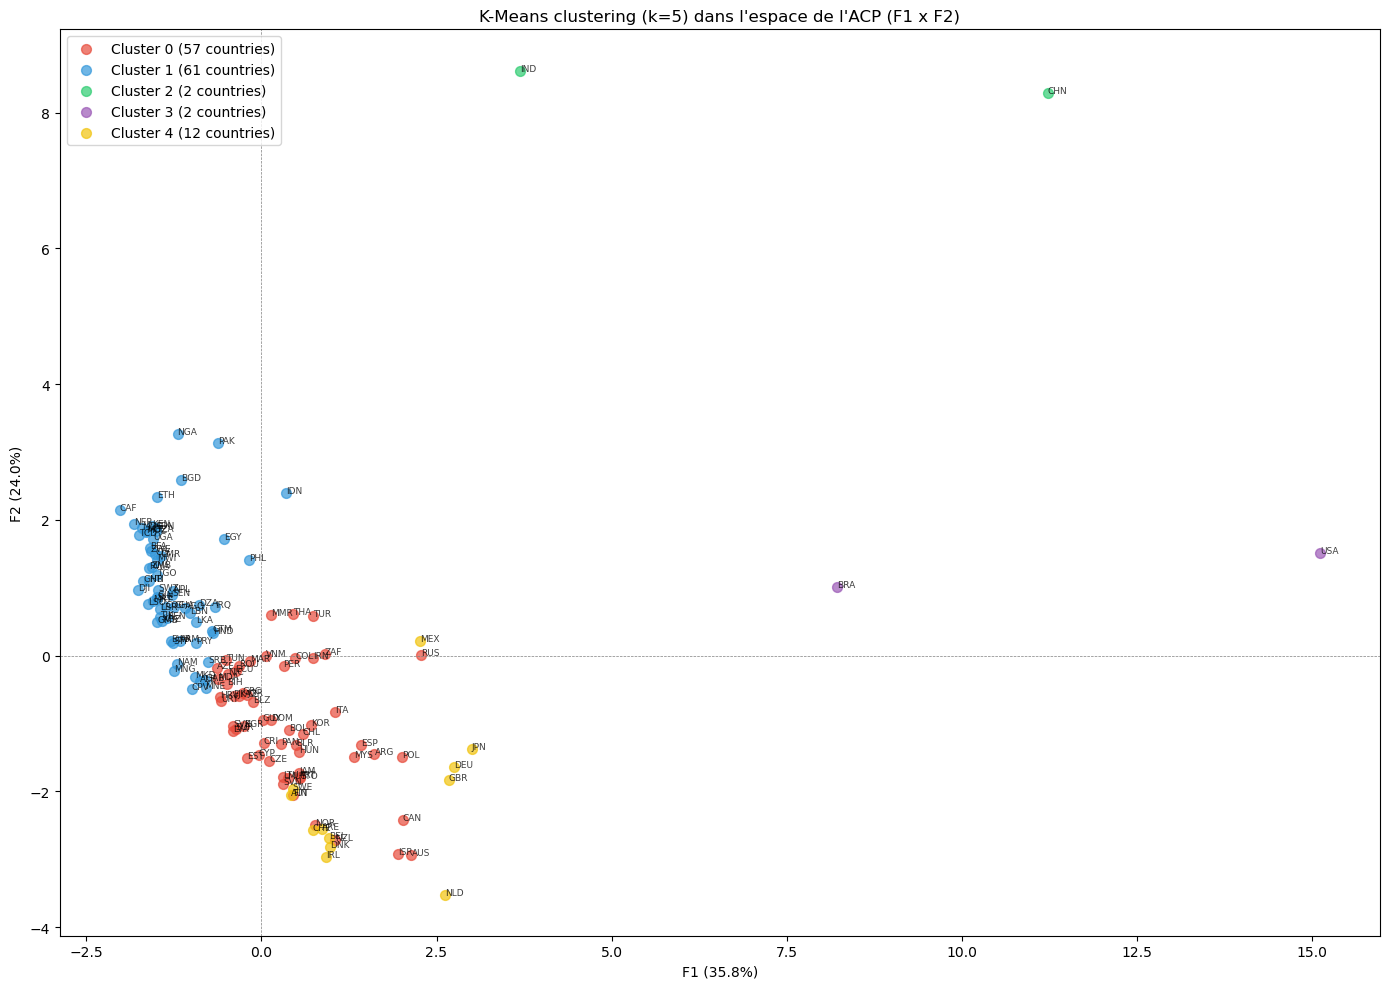

In [24]:
fig, ax = plt.subplots(figsize=(14, 10))

# couleur des clusters
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6', '#F1C40F']

for cluster in range(5):
    # On utilise bien df_coords pour le masque du cluster
    mask = df_coords['cluster'] == cluster
    
    ax.scatter(
        df_pca.loc[mask, 'F1'],
        df_pca.loc[mask, 'F2'],
        c=colors[cluster],
        label=f'Cluster {cluster} ({mask.sum()} countries)',
        alpha=0.7,
        s=50
    )

# Étiquettes des pays (inchangé, mais bien basé sur df_pca)
for country in df_pca.index:
    ax.annotate(
        country,
        xy=(df_pca.loc[country, 'F1'],
            df_pca.loc[country, 'F2']),
        fontsize=6.5,
        alpha=0.75
    )

# Axes, labels et titre mis à jour (k=5)
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax.set_xlabel(f'F1 ({scree[0]:.1f}%)')
ax.set_ylabel(f'F2 ({scree[1]:.1f}%)')
ax.set_title("K-Means clustering (k=5) dans l'espace de l'ACP (F1 x F2)")
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

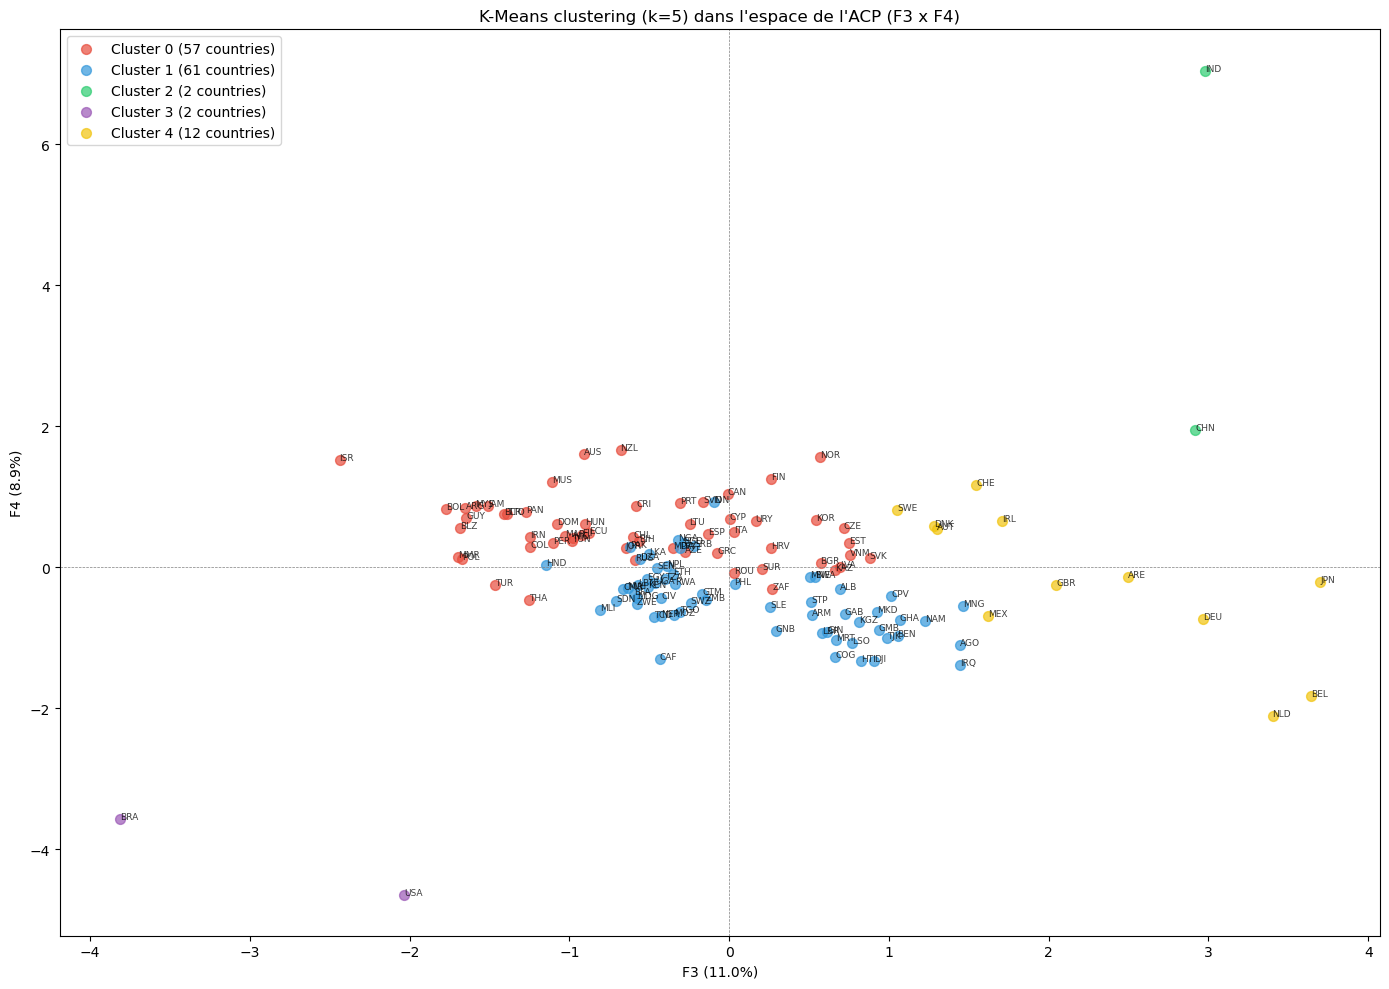

In [25]:
fig, ax = plt.subplots(figsize=(14, 10))

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6', '#F1C40F']

# Boucle pour parcourir les 5 clusters
for cluster in range(5):
    mask = df_coords['cluster'] == cluster
    
    ax.scatter(
        df_pca.loc[mask, 'F3'],
        df_pca.loc[mask, 'F4'],
        c=colors[cluster],
        label=f'Cluster {cluster} ({mask.sum()} countries)',
        alpha=0.7,
        s=50
    )

# Annotation des pays avec leurs coordonnées F3 et F4
for country in df_pca.index:
    ax.annotate(
        country,
        xy=(df_pca.loc[country, 'F3'],
            df_pca.loc[country, 'F4']),
        fontsize=6.5,
        alpha=0.75
    )

# Axes, labels et titre mis à jour
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

ax.set_xlabel(f'F3 ({scree[2]:.1f}%)')
ax.set_ylabel(f'F4 ({scree[3]:.1f}%)')
ax.set_title("K-Means clustering (k=5) dans l'espace de l'ACP (F3 x F4)")
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [26]:
# Force la création d'un vrai DataFrame basé uniquement sur df_pca
df_analyse = pd.DataFrame(df_pca.copy())

# Demande au modèle K-Means de recalculer les labels EN DIRECT pour être SÛR à 100% d'avoir un array propre et pas une liste résiduelle
df_analyse['cluster'] = km.labels_

# Calcul des moyennes sur les axes de l'ACP
profil_clusters = df_analyse.groupby('cluster').mean().T
profil_clusters.columns = [f'Cluster {c}' for c in profil_clusters.columns]

profil_clusters.round(2)

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
F1,0.35,-1.26,7.46,11.66,1.55
F2,-0.99,1.03,8.46,1.26,-2.15
F3,-0.57,0.10,2.95,-2.92,2.23
F4,0.53,-0.47,4.50,-4.11,-0.18


<div style="background-color: RGB(150, 20, 30);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">FIN</h2>
</div>

In [27]:
print("FINI")

FINI
